In [3]:
# Blessing Anoroh
# Project 2 - TMDB 5000 Network
# DATA 620 - Web Analytics
# March 23, 2026 (Due)

 **Introduction**

 In this project we will be analyzing a two-mode (bipartite) network using movie and actor data from the TMDB 5000 dataset. In this network, one group represents actors and the other represents movies, with connections indicating that an actor appeared in a movie. This structure ensures that ties occur between two distinct groups rather than within the same group.

To better understand the relationships in the network, the bipartite graph is projected onto actors to examine collaboration patterns. The network is then reduced using an island-style threshold to focus on stronger, repeated connections. This approach highlights meaningful patterns in the data and allows for clearer interpretation of how actors and movies contribute to collaboration within the film industry.

Source: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata?resource=download

In [1]:
# Step 1: Import packages
import os
from pathlib import Path
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Step 2: folder path
base_path = Path("/Users/blessinga/Desktop/Masters Data Science/Data 620 - web analytics/project 2/Top_Movie_Dataset")


if base_path.exists():
    print("\nFiles in folder:")
    for f in base_path.iterdir():
        print(f.name)

# Step 3: File paths
from google.colab import files
uploaded = files.upload()



Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv


In [2]:
credits = pd.read_csv("tmdb_5000_credits.csv")
movies = pd.read_csv("tmdb_5000_movies.csv")

print(credits.head())

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4  [{"credit_id": "52fe479ac3a36847f813eaa3",

In [4]:
# Step 4: Keep only needed columns
credits = credits[['movie_id', 'title', 'cast']]

# Check shape and missing values
print("Shape before cleaning:", credits.shape)
print(credits.isnull().sum())

Shape before cleaning: (4803, 3)
movie_id    0
title       0
cast        0
dtype: int64


In [5]:
# Step 5: Remove missing values
credits = credits.dropna(subset=['movie_id', 'title', 'cast'])

# Remove duplicate movies
credits = credits.drop_duplicates(subset=['movie_id', 'title'])

print("Shape after basic cleaning:", credits.shape)

Shape after basic cleaning: (4803, 3)


In [6]:
# Step 6: Make sure IDs and titles are clean
credits['movie_id'] = credits['movie_id'].astype(str)
credits['title'] = credits['title'].astype(str).str.strip()

print(credits.dtypes)
credits.head()

movie_id    object
title       object
cast        object
dtype: object


,movie_id,title,cast
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c..."


In [7]:
#using import ast

# Convert cast column from string to list
credits['cast'] = credits['cast'].apply(ast.literal_eval)

# Quick check
print(type(credits['cast'].iloc[0]))
print(credits['cast'].iloc[0][:2])

<class 'list'>
[{'cast_id': 242, 'character': 'Jake Sully', 'credit_id': '5602a8a7c3a3685532001c9a', 'gender': 2, 'id': 65731, 'name': 'Sam Worthington', 'order': 0}, {'cast_id': 3, 'character': 'Neytiri', 'credit_id': '52fe48009251416c750ac9cb', 'gender': 1, 'id': 8691, 'name': 'Zoe Saldana', 'order': 1}]


In [8]:
# Step 7: Create actor-movie edge list
rows = []

for _, row in credits.iterrows():
    movie = row['title']
    for actor in row['cast']:
        actor_name = actor['name']
        rows.append((actor_name, movie))

actor_movie_df = pd.DataFrame(rows, columns=['actor', 'movie'])

# Clean edge list
actor_movie_df = actor_movie_df.dropna()
actor_movie_df['actor'] = actor_movie_df['actor'].astype(str).str.strip()
actor_movie_df['movie'] = actor_movie_df['movie'].astype(str).str.strip()
actor_movie_df = actor_movie_df.drop_duplicates()

print("Actor-movie edge list shape:", actor_movie_df.shape)
actor_movie_df.head()


Actor-movie edge list shape: (106076, 2)


,actor,movie
0,Sam Worthington,Avatar
1,Zoe Saldana,Avatar
2,Sigourney Weaver,Avatar
3,Stephen Lang,Avatar
4,Michelle Rodriguez,Avatar


I cleaned the dataset by keeping only the movie ID, title, and cast columns, removing missing values and duplicates, standardizing data types, and converting the cast field into a usable list format. I then created a clean actor–movie edge list for the bipartite network.

In [9]:
# Check for overlap between actor and movie names
overlap = set(actor_movie_df['actor']).intersection(set(actor_movie_df['movie']))
print("Number of overlapping names:", len(overlap))
print("Examples:", list(overlap)[:10])

Number of overlapping names: 11
Examples: ['Beetlejuice', 'Jackie Brown', 'Tom Jones', 'Scarface', 'Wyatt Earp', 'John Carter', 'The Edge', 'Erin Brockovich', 'Carlos', 'Michael Collins']


In [10]:
# Step 8: Build bipartite graph correctly
B = nx.Graph()

# Add actor nodes with prefix
actor_nodes = ["actor_" + actor for actor in actor_movie_df['actor'].unique()]

# Add movie nodes with prefix
movie_nodes = ["movie_" + movie for movie in actor_movie_df['movie'].unique()]

B.add_nodes_from(actor_nodes, bipartite='actor')
B.add_nodes_from(movie_nodes, bipartite='movie')

# Add edges with prefixes
for _, row in actor_movie_df.iterrows():
    actor_node = "actor_" + row['actor']
    movie_node = "movie_" + row['movie']
    B.add_edge(actor_node, movie_node)

# Check if Bipartite
print("Is bipartite?", nx.is_bipartite(B))
print("Number of nodes:", B.number_of_nodes())
print("Number of edges:", B.number_of_edges())
print("Number of actor nodes:", len(actor_nodes))
print("Number of movie nodes:", len(movie_nodes))

Is bipartite? True
Number of nodes: 58955
Number of edges: 106076
Number of actor nodes: 54198
Number of movie nodes: 4757


To ensure the network remained truly bipartite, I assigned separate prefixes to actor and movie nodes. This prevented cases where the same text label appeared in both groups and was incorrectly treated as a single node.

In [11]:
# Step 9: Extract actor nodes
actor_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "actor"]

# Project bipartite graph onto actors
from networkx.algorithms import bipartite

G_actor = bipartite.weighted_projected_graph(B, actor_nodes)

print("Projected actor network")
print("Number of nodes:", G_actor.number_of_nodes())
print("Number of edges:", G_actor.number_of_edges())

Projected actor network
Number of nodes: 54198
Number of edges: 1998074


In [12]:
# Step 10: Reduce network using threshold
threshold = 3   # actors must have appeared together in at least 3 movies

G_actor_island = nx.Graph(
    (u, v, d) for u, v, d in G_actor.edges(data=True) if d["weight"] >= threshold
)

print("Reduced actor network")
print("Number of nodes:", G_actor_island.number_of_nodes())
print("Number of edges:", G_actor_island.number_of_edges())

Reduced actor network
Number of nodes: 1692
Number of edges: 5013


In [13]:
# Step 11: Keep largest connected component
largest_cc = max(nx.connected_components(G_actor_island), key=len)
G_actor_core = G_actor_island.subgraph(largest_cc).copy()

print("Core actor network")
print("Number of nodes:", G_actor_core.number_of_nodes())
print("Number of edges:", G_actor_core.number_of_edges())

Core actor network
Number of nodes: 1271
Number of edges: 4674


In [14]:
# Step 12: Centrality measures
degree_dict = dict(G_actor_core.degree())
weighted_degree_dict = dict(G_actor_core.degree(weight="weight"))
betweenness_dict = nx.betweenness_centrality(G_actor_core)

top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_weighted = sorted(weighted_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness = sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 actors by degree:")
for actor, val in top_degree:
    print(actor, val)

print("\nTop 10 actors by weighted degree:")
for actor, val in top_weighted:
    print(actor, val)

print("\nTop 10 actors by betweenness:")
for actor, val in top_betweenness:
    print(actor, val)

Top 10 actors by degree:
actor_Samuel L. Jackson 44
actor_Alan Rickman 43
actor_John Ratzenberger 43
actor_Stan Lee 42
actor_Ian McKellen 41
actor_Timothy Spall 41
actor_Maggie Smith 39
actor_Hugo Weaving 38
actor_Robbie Coltrane 38
actor_Seth Rogen 37

Top 10 actors by weighted degree:
actor_Alan Rickman 201
actor_Maggie Smith 186
actor_Robbie Coltrane 181
actor_Adam Sandler 180
actor_David Bradley 174
actor_Emma Watson 172
actor_Geraldine Somerville 172
actor_Daniel Radcliffe 172
actor_Warwick Davis 171
actor_Rupert Grint 170

Top 10 actors by betweenness:
actor_Samuel L. Jackson 0.11737971797444598
actor_John Turturro 0.09483799398677682
actor_Elizabeth Banks 0.08013398681382253
actor_Ben Stiller 0.07784385391344138
actor_Robert De Niro 0.0761997259037075
actor_Hugo Weaving 0.07543199356551225
actor_Stan Lee 0.06840230000110134
actor_Simon Pegg 0.06750305238937879
actor_Steve Buscemi 0.06744639284233592
actor_Bill Hader 0.06500116496607894


The results show that actors play different roles in the network depending on the measure used. Actors like Samuel L. Jackson and Alan Rickman have high degree, meaning they collaborate with many others. High weighted degree actors, such as Maggie Smith and other Harry Potter cast members, tend to work repeatedly with the same group. Betweenness centrality highlights actors like Samuel L. Jackson and Robert De Niro as bridges connecting different parts of the network. Overall, the network shows a mix of highly connected actors, tightly grouped collaborations, and key connectors linking different clusters.

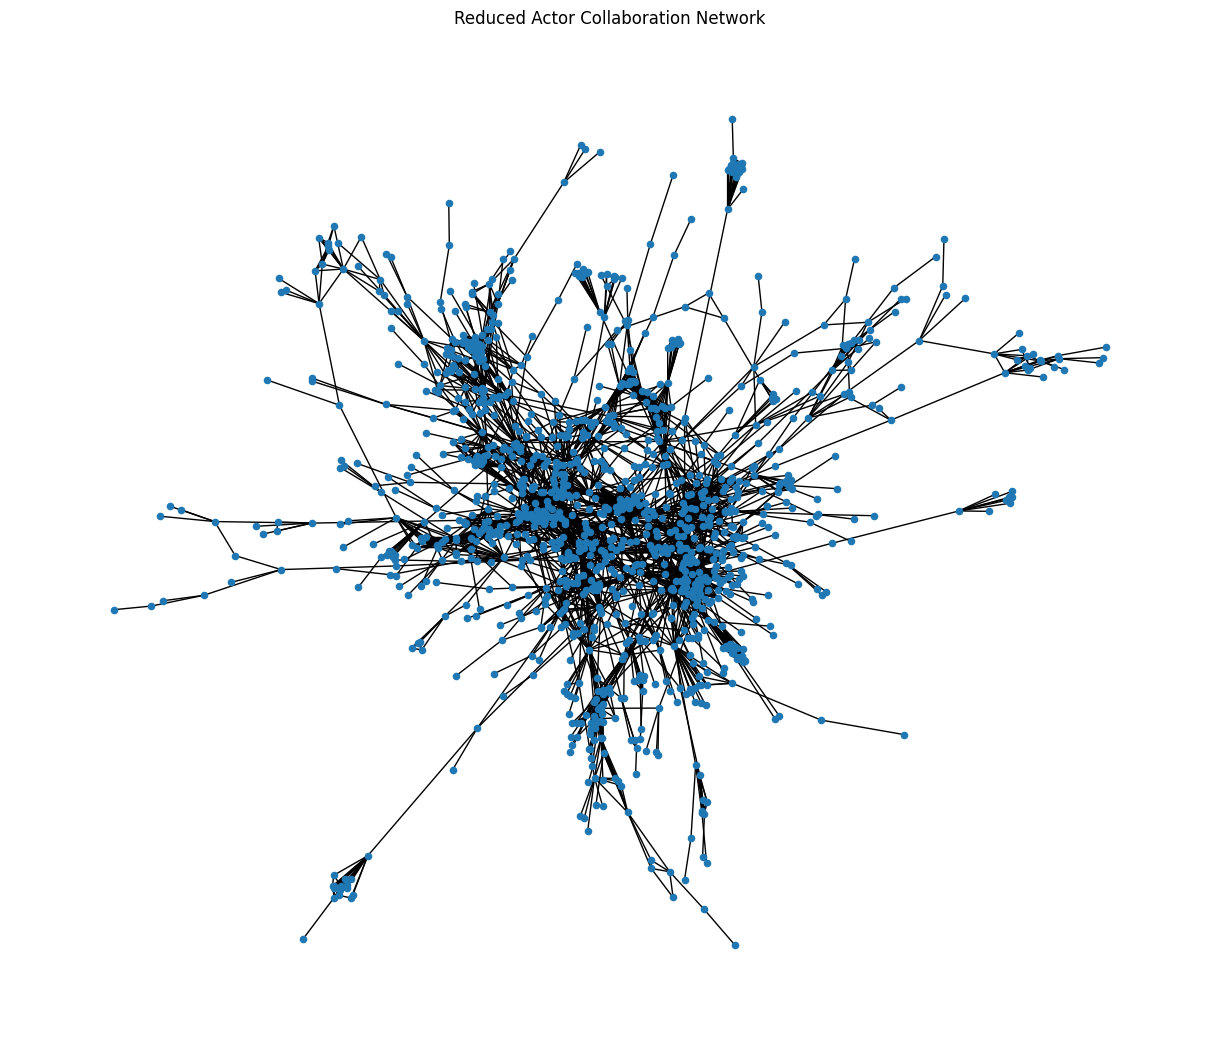

In [15]:
# Step 13: Visualize reduced network
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_actor_core, seed=42)
nx.draw(G_actor_core, pos, node_size=20, with_labels=False)
plt.title("Reduced Actor Collaboration Network")
plt.show()

The visualization shows the reduced actor collaboration network after applying the island method. The network is much more compact compared to the original, with a dense central cluster and several smaller branches extending outward. The central cluster represents actors who frequently collaborate and are highly connected, while the outer nodes represent actors with fewer or more specialized connections. This structure highlights a core-periphery pattern, where a tightly connected group forms the center of the network and less connected actors appear on the edges.

# **Conclusion**


This project used a bipartite network of actors and movies, where connections represent an actor appearing in a movie. After projecting onto actors and applying an island threshold, the network highlights stronger collaboration patterns.

From the actor group, some actors like Samuel L. Jackson and Alan Rickman are highly connected, while others show repeated collaborations within specific groups, such as the Harry Potter cast. Actors with high betweenness act as bridges connecting different clusters.

From the movie group, certain movies especially those with large or recurring casts ***play a key role in forming clusters and connecting actors***.

Overall, the network shows a core group of highly connected actors, smaller collaboration clusters, and key connections shaped by both actors and movies.